In [1]:
import json
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))
# my utils
from utils import fa
from utils import modeling
from utils import preprocess_listings

In [2]:
# 标准版存档V0：
LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}


In [3]:
DATA_DIR="../data_processed"
groups=[   
    'london_2306', "london_2312",'london_2406',
    'paris_2306',"paris_2312","paris_2406"
]
list_df=[]
for g in groups:
    path_df=os.path.join(DATA_DIR, g, f"listings_zsc_{g}.csv")
    print(f"{g}".center(100,'-'))
    print(path_df,os.path.exists(path_df))
    
    df=pd.read_csv(path_df)
    print(df.shape)
    time=g.split("_")[1]
    in_paris="1" if g.split('_')[0]=="paris" else 0
    df["group"]=g
    df['time']=str(time)
    df['post'] = df["time"].apply(lambda x : 1 if x=="2406" else 0)
    df['in_paris']=in_paris

    # check
    if "len" in df:
        df.rename(columns={'len':"text_length"},inplace=True)

    # double check
    df['has_text']=df['lang'].apply(lambda x : 0 if x=="no_text" else 1)
    df['lang_fr']=df['lang'].apply(lambda x : 1 if x=="fr" else 0)
    df['lang_en']=df['lang'].apply(lambda x : 1 if x=="en" else 0)       
        
    list_df.append(df)
df_zsc=pd.concat(list_df, axis=0)
print(df_zsc.shape)

--------------------------------------------london_2306---------------------------------------------
../data_processed\london_2306\listings_zsc_london_2306.csv True
(42356, 108)
--------------------------------------------london_2312---------------------------------------------
../data_processed\london_2312\listings_zsc_london_2312.csv True
(43172, 112)
--------------------------------------------london_2406---------------------------------------------
../data_processed\london_2406\listings_zsc_london_2406.csv True
(49856, 108)
---------------------------------------------paris_2306---------------------------------------------
../data_processed\paris_2306\listings_zsc_paris_2306.csv True


C:\Users\yeliu\AppData\Local\Temp\ipykernel_33360\1366755178.py:12: DtypeWarning: Columns (59,60) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path_df)


(32901, 108)
---------------------------------------------paris_2312---------------------------------------------
../data_processed\paris_2312\listings_zsc_paris_2312.csv True
(35829, 114)
---------------------------------------------paris_2406---------------------------------------------
../data_processed\paris_2406\listings_zsc_paris_2406.csv True
(62738, 107)
(266852, 116)


## fa :

[INFO] all output saved to '..\C_bio\output_fa_all_20260530'!
df with fa scores saved to '..\data_all' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!

============================RUN FA=================================
[info] df_zsc: 266852 rows; df_items:63085 rows!

[INFO] kmo_model score (> 0.7) :0.8753547002171318

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


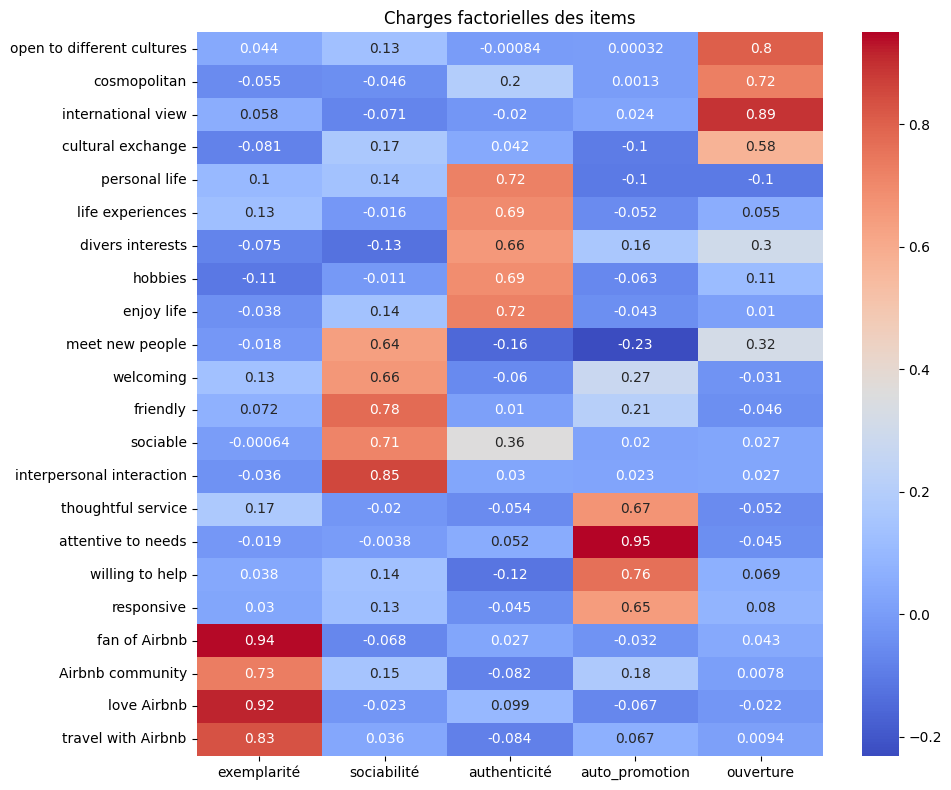

✅ [SAVE] heatmap of items saved to ..\C_bio\output_fa_all_20260530\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\C_bio\output_fa_all_20260530\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:187: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:187: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:187: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please 

,ouverture,authenticité,sociabilité,auto_promotion,exemplarité,communalité,unicité,complexité
open to different cultures,0.8026,-,-,-,-,0.663206,0.336794,1.059173
cosmopolitan,0.7241,-,-,-,-,0.567967,0.432033,1.167173
international view,0.8901,-,-,-,-,0.801756,0.198244,1.023811
cultural exchange,0.5752,-,-,-,-,0.376675,0.623325,1.285862
personal life,-,0.7233,-,-,-,0.574894,0.425106,1.204384
life experiences,-,0.6946,-,-,-,0.504694,0.495306,1.093209
divers interests,-,0.6582,-,-,-,0.574083,0.425917,1.671489
hobbies,-,0.6877,-,-,-,0.501230,0.498770,1.121904
enjoy life,-,0.7221,-,-,-,0.544256,0.455744,1.087708
meet new people,-,-,0.6382,-,-,0.586083,0.413917,1.914109


[INFO] mean COMM (> 0.6):0.6253863663812775
[INFO] mean UNIQ : 0.37461363361872235

[WARNING] 3/22 low communality items (< 0.5):
cultural exchange;thoughtful service;responsive

✅ [SAVE] items fa CSV saved to ..\C_bio\output_fa_all_20260530\items_fa.csv!

☑️[SAVE] Table saved as LaTeX to ..\C_bio\output_fa_all_20260530\latex\items_fa.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
WEIGHTED ORDER:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
[INFO] shape df scores = 5*len(get_factor_scores_by):(63085, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Dimension 1,Dimension 2
ouverture,-0.052861,0.726418
authenticité,-0.142240,0.572374
sociabilité,0.490147,0.449752
auto_promotion,0.993477,-0.057141
exemplarité,0.501839,0.018273


✅[SAVE] scores df saved to ..\C_bio\output_fa_all_20260530\scores_fa.csv!
☑️[SAVE] Table saved as LaTeX to ..\C_bio\output_fa_all_20260530\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


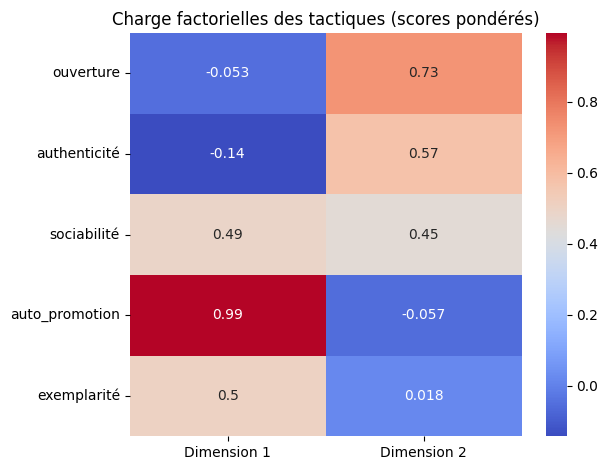

✅ [SAVE] heatmap of pondérés scores saved to ..\C_bio\output_fa_all_20260530\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,in_paris,has_text,lang_fr,lang_en,langue,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,157714.0,https://www.airbnb.com/rooms/157714,2.023061e+13,2023-06-09,city scrape,Townhouse in Hammersmith · ★4.71 · 1 bedroom ·...,"Large, light and spacious loft bedroom with a ...",The neighbourhood is extremely convenient for ...,https://a0.muscache.com/pictures/4129744/10db5...,757377.0,...,0,1,0,1,NaN,0.161147,-0.665889,0.980910,1.339927,0.203598
1,13913.0,https://www.airbnb.com/rooms/13913,2.023061e+13,2023-06-09,city scrape,Rental unit in Islington · ★4.80 · 1 bedroom ·...,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730.0,...,0,1,0,1,NaN,0.930145,0.438044,-1.296640,-0.974180,-0.723171
2,15400.0,https://www.airbnb.com/rooms/15400,2.023061e+13,2023-06-09,city scrape,Rental unit in London · ★4.80 · 1 bedroom · 1 ...,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302.0,...,0,1,0,1,NaN,1.023326,1.203827,-0.668133,-0.568512,1.350431
3,306333.0,https://www.airbnb.com/rooms/306333,2.023061e+13,2023-06-09,city scrape,Rental unit in London · ★4.32 · 2 bedrooms · 3...,Welcome to my lovely 2-bedroom flat in Hoxton!...,"In Shoreditch, empty walls are future murals. ...",https://a0.muscache.com/pictures/32c818d1-7762...,1573870.0,...,0,1,0,1,NaN,-0.125047,1.364940,-0.258796,-0.936774,-0.637748
4,159736.0,https://www.airbnb.com/rooms/159736,2.023061e+13,2023-06-09,city scrape,Rental unit in Lambeth · ★4.72 · 1 bedroom · 1...,Calm sunny double room with a queen size bed a...,We love that in Loughborough Junction we live ...,https://a0.muscache.com/pictures/1067303/d2300...,766056.0,...,0,1,0,1,NaN,0.158115,-0.610320,0.902967,1.719308,0.633420


[INFO] scores shape (len(data), 1/2*n_factors) :(63085, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 63085, 63085, 63085
len(DF)==len(listings_tactics):266852,266852

✅ [SAVE] 266852 listings with tactics scores by 'weighted' way saved to ..\data_all\listings_tactics-paris_london-2306_2312_2406-1.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.856336
1,authenticité,0.852067
2,sociabilité,0.876415
3,auto_promotion,0.875476
4,exemplarité,0.920562


✅ [SAVE] cronbach's alpha on items saved to ..\C_bio\output_fa_all_20260530\cronbachs_alpha.csv!


-----------------------------barplot comm&uniq-------------------------------
[info] good communality (h²) : > 0.3; specificity=1-communality
[INFO] mean COMM (> 0.6):0.6253863663812775
[INFO] mean UNIQ : 0.37461363361872235

[info] good item:gamma > 0.5 + sigma < 0.3


<Figure size 1000x600 with 0 Axes>

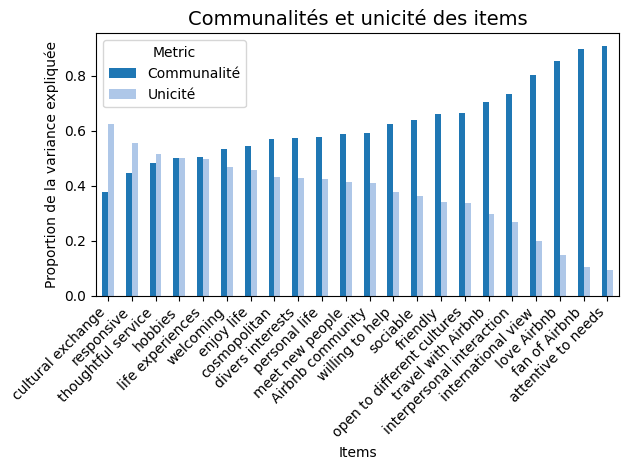

✅ [SAVE] barplot saved to ..\C_bio\output_fa_all_20260530\comm_uniq_barplot.jpg!

# -----------------------------3D PCA-------------------------------
[INFO] Explained variance ratios 3D (>0.6): 0.782001231660038


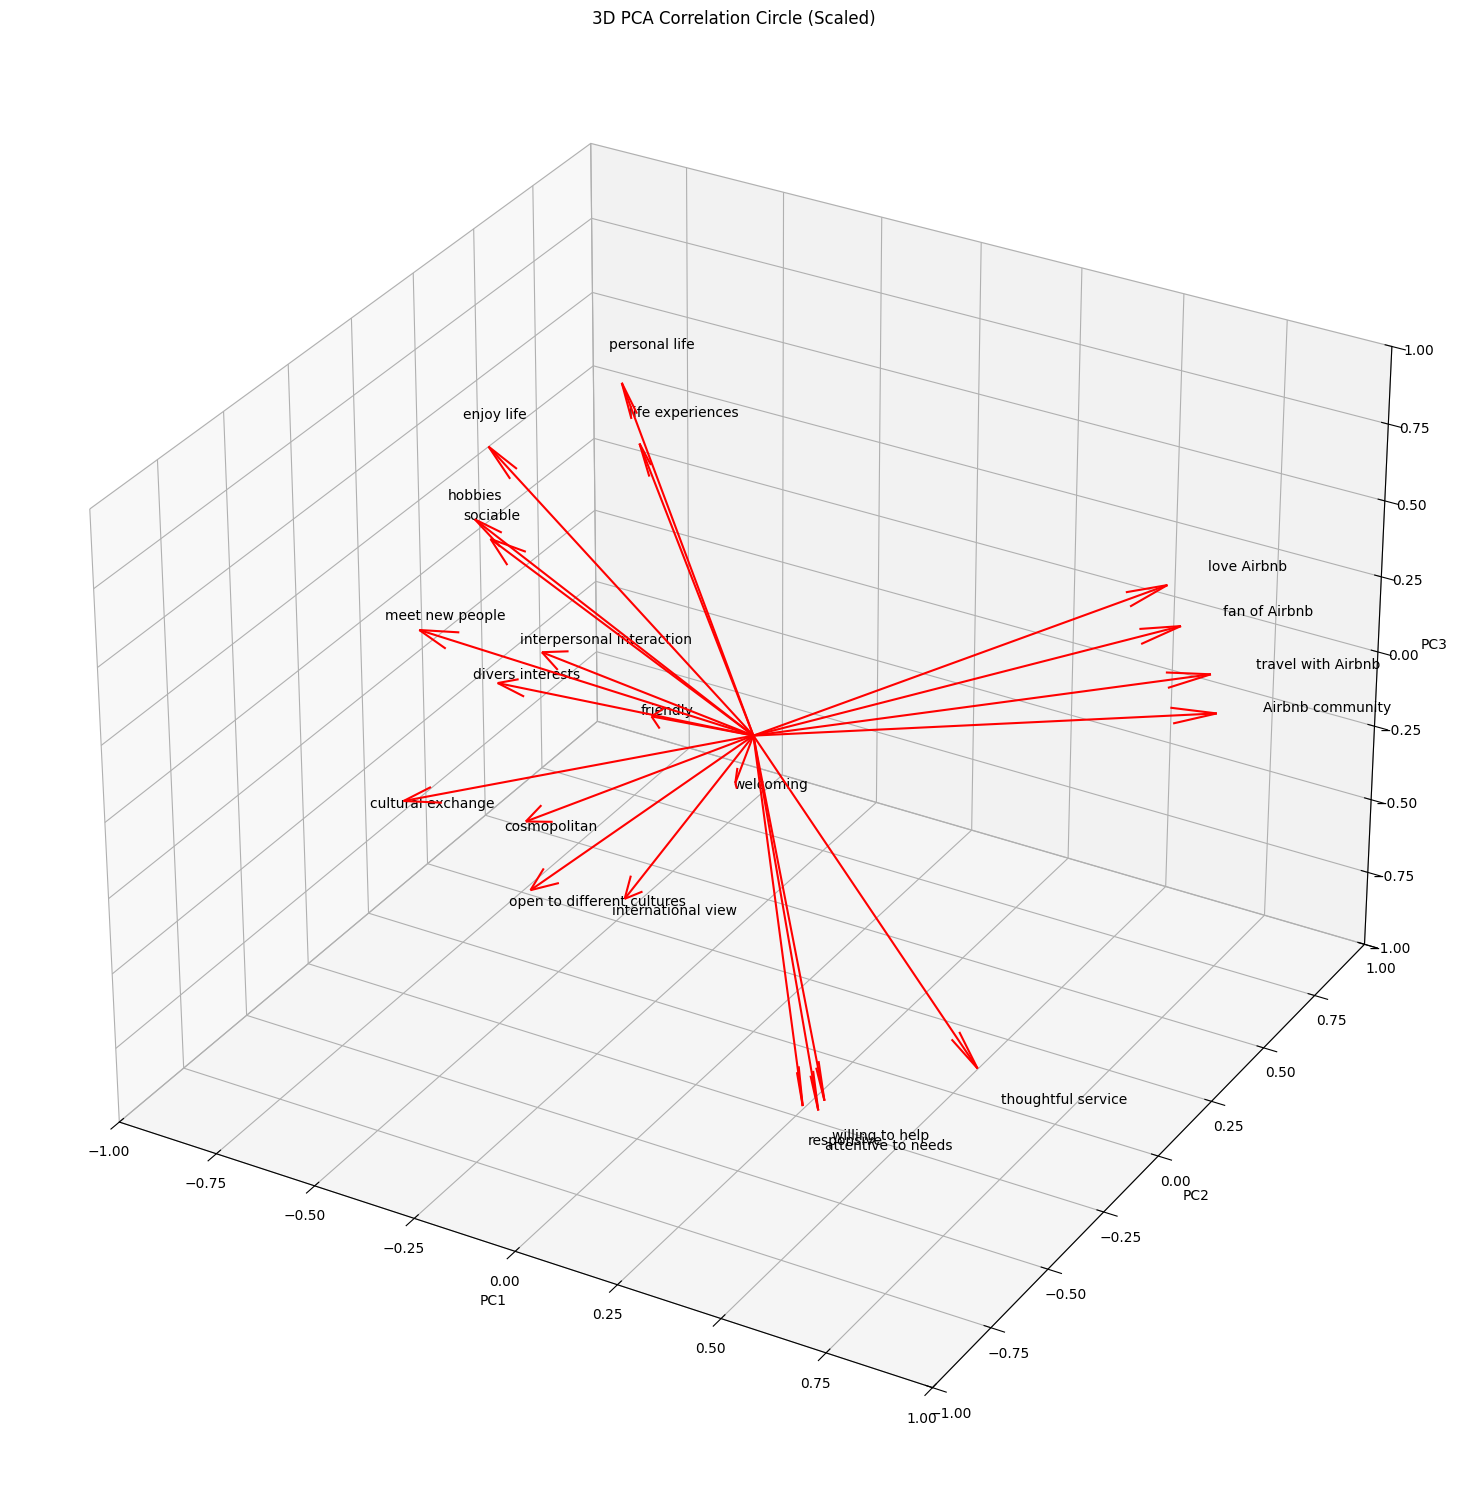

✅ [SAVE] PCA 3D saved to ..\C_bio\output_fa_all_20260530\pca_3d.jpg!



In [4]:
importlib.reload(fa)
from utils.fa import run_fa

OUTPUT_FOLDER=Path("../C_bio/output_fa_all_20260530")
OUTPUT_FOLDER_DATA=Path("../data_all")

df_zsc=df_zsc.copy()
listings_tactics=run_fa(df_zsc=df_zsc, items=LABELS_EN, 
    output_folder=OUTPUT_FOLDER,
    output_folder_data=OUTPUT_FOLDER_DATA,filename="listings_tactics-paris_london-2306_2312_2406-1.csv",
    
    n_factors=5, rotation="oblimin",
    fa_names=["exemplarité","sociabilité","authenticité","auto_promotion", "ouverture"],#check order!!
    dict_factor_items=DICT_FACTOR_ITEMS,
    get_items_heatmap=True,
    get_items_table=True, low_comm_t=0.5,
    get_factor_scores_by='weighted',
    run_fa_on_scores="weighted",
    get_scores_heatmap=True,
    get_cronbachs_a=True,
    get_barplot=True, get_pca3d=True, 
    ndigits=4)